In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()
if os.getenv("GROQ_API_KEY"):
    print("API Key Is Set")
else:
    raise ValueError("API Key Is Not Set")

API Key Is Set


In [2]:
from langchain_groq import ChatGroq
llm = ChatGroq(model = "openai/gpt-oss-120b")

In [3]:
from typing import TypedDict, List, Annotated
from operator import add

class graph_schema(TypedDict):
    messages_manual : List
    # messages_auto : Annotated[List,add]
    

In [4]:
from langchain_core.messages import AIMessage, HumanMessage

def create_post(state:graph_schema) -> graph_schema:
    
    #convert the pydantic model to a dictionary
    
    messages_manual = state['messages_manual']
    
    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content = response_manual)
    
    state['messages_manual'] = messages_manual + [response_manual_ai]
    
    return state

def curate_post(state: graph_schema) -> graph_schema:
    
    messages_manual = state['messages_manual']
    
    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(response_manual)
    
    state['messages_manual'] = messages_manual + [response_manual_ai]
    
    return state
    

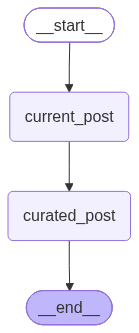

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("current_post",create_post)
graph.add_node("curated_post",curate_post)

graph.add_edge(START, "current_post")
graph.add_edge("current_post","curated_post")
graph.add_edge("curated_post",END)

final_graph = graph.compile()
final_graph

In [6]:
final_graph.invoke({"messages_manual":[HumanMessage(content = "The Silicon Valley of india")]})

{'messages_manual': [HumanMessage(content='The Silicon Valley of india', additional_kwargs={}, response_metadata={}),
  AIMessage(content='**Bangalore (Bengaluru) –\u202fthe “Silicon Valley of India”**\n\n| Aspect | Details |\n|--------|---------|\n| **Why the nickname?** | • First Indian city to attract a massive concentration of tech‑focused multinational corporations, startups, and research institutions.<br>• Home to the largest pool of software engineers in the country.<br>• The ecosystem mirrors many of the network effects that made California’s Silicon Valley famous. |\n| **Key milestones** | • 1980s‑90s: Arrival of early IT giants (Infosys, Wipro, Tata Consultancy Services).<br>• 1999‑2004: Dot‑com boom → explosion of BPOs and software parks.<br>• 2008‑present: Startup surge – >10,000 startups, several “unicorns” (e.g., Flipkart, Ola, Swiggy, Byju’s). |\n| **Major tech hubs & parks** | • **Electronic City** – one of the largest IT parks in Asia.<br>• **International Tech Park (I